# 第二次作业：CNN实现SVHN图像分类任务

使用SVHN Format2数据集，通过设计并训练卷积神经网络（CNN），实现对街景门牌数字的图像分类任务（0-9共10类）。

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import os
import urllib.request

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

使用设备: cuda


## 1. 数据下载与加载

In [7]:
# 下载SVHN Format2数据集
data_dir = './data'
os.makedirs(data_dir, exist_ok=True)

urls = {
    'train_32x32.mat': 'http://ufldl.stanford.edu/housenumbers/train_32x32.mat',
    'test_32x32.mat': 'http://ufldl.stanford.edu/housenumbers/test_32x32.mat'
}

for fname, url in urls.items():
    fpath = os.path.join(data_dir, fname)
    if not os.path.exists(fpath):
        print(f'正在下载 {fname} ...')
        urllib.request.urlretrieve(url, fpath)
        print(f'{fname} 下载完成')
    else:
        print(f'{fname} 已存在，跳过下载')

# 加载.mat文件
train_data = sio.loadmat(os.path.join(data_dir, 'train_32x32.mat'))
test_data = sio.loadmat(os.path.join(data_dir, 'test_32x32.mat'))

# X: (32, 32, 3, N) -> (N, 3, 32, 32), y: (N, 1) -> (N,)
X_train = train_data['X'].transpose(3, 2, 0, 1).astype(np.float32)
y_train = train_data['y'].flatten()
X_test = test_data['X'].transpose(3, 2, 0, 1).astype(np.float32)
y_test = test_data['y'].flatten()

# 标签10 -> 0（SVHN中数字0的标签是10）
y_train[y_train == 10] = 0
y_test[y_test == 10] = 0

print(f'训练集: {X_train.shape}, 标签: {y_train.shape}')
print(f'测试集: {X_test.shape}, 标签: {y_test.shape}')
print(f'类别分布(训练): {np.bincount(y_train)}')

train_32x32.mat 已存在，跳过下载
test_32x32.mat 已存在，跳过下载
训练集: (73257, 3, 32, 32), 标签: (73257,)
测试集: (26032, 3, 32, 32), 标签: (26032,)
类别分布(训练): [ 4948 13861 10585  8497  7458  6882  5727  5595  5045  4659]


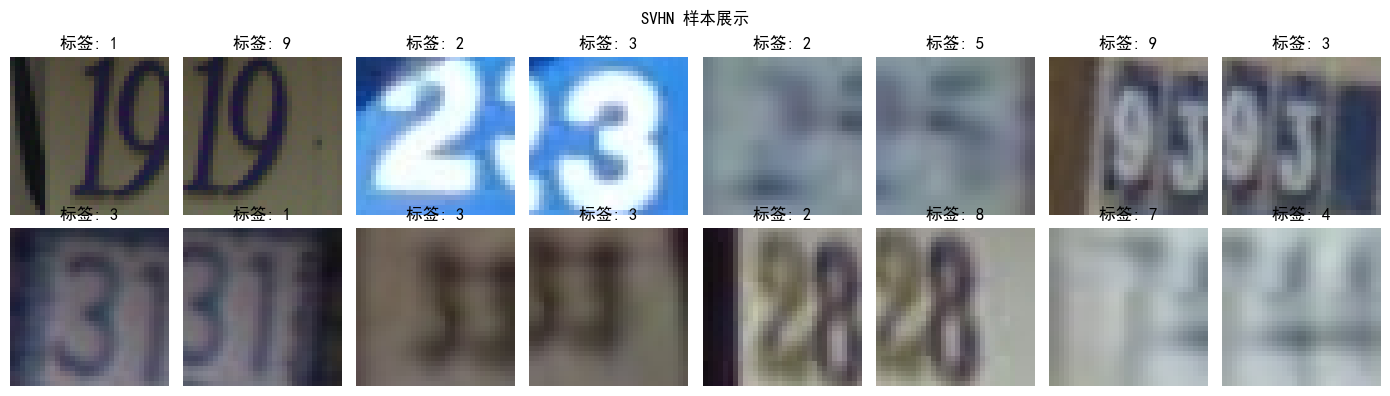

In [8]:
# 可视化部分样本
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = X_train[i].transpose(1, 2, 0).astype(np.uint8)
    ax.imshow(img)
    ax.set_title(f'标签: {y_train[i]}')
    ax.axis('off')
plt.suptitle('SVHN 样本展示')
plt.tight_layout()
plt.show()

## 2. 数据预处理与数据增强

In [9]:
class SVHNDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]  # (3, 32, 32) float32
        label = int(self.labels[idx])
        img = torch.from_numpy(img).byte() if img.max() > 1 else torch.from_numpy((img * 255).astype(np.uint8))
        img = transforms.ToPILImage()(img)
        if self.transform:
            img = self.transform(img)
        return img, label

# 数据增强
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4377, 0.4438, 0.4728), (0.1980, 0.2010, 0.1970))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4377, 0.4438, 0.4728), (0.1980, 0.2010, 0.1970))
])

train_dataset = SVHNDataset(X_train, y_train, transform=train_transform)
test_dataset = SVHNDataset(X_test, y_test, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

print(f'训练集批次数: {len(train_loader)}')
print(f'测试集批次数: {len(test_loader)}')

训练集批次数: 573
测试集批次数: 102


## 3. 构建CNN模型（ResNet风格）

采用残差连接的CNN结构，GPU加速训练。

In [10]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out


class SVHNResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.layer1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = [ResidualBlock(in_channels, out_channels, stride)]
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


assert torch.cuda.is_available(), "CUDA不可用！请检查GPU驱动和PyTorch安装"
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'显存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

model = SVHNResNet(num_classes=10).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'模型总参数量: {total_params:,}')
print(f'模型已加载到: {device}')

GPU: NVIDIA GeForce RTX 5070
显存: 11.9 GB
模型总参数量: 11,173,962
模型已加载到: cuda


## 4. 定义损失函数与优化器

In [11]:
NUM_EPOCHS = 30

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f'损失函数: CrossEntropyLoss')
print(f'优化器: Adam (lr=1e-3, weight_decay=1e-4)')
print(f'学习率调度: CosineAnnealingLR')
print(f'训练轮数: {NUM_EPOCHS}')

损失函数: CrossEntropyLoss
优化器: Adam (lr=1e-3, weight_decay=1e-4)
学习率调度: CosineAnnealingLR
训练轮数: 30


## 5. 训练与评估

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

In [13]:
import time

# 训练循环
train_losses, test_losses = [], []
train_accs, test_accs = [], []
best_test_acc = 0

total_start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step()
    epoch_time = time.time() - epoch_start

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print(f'Epoch [{epoch:2d}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | '
          f'LR: {scheduler.get_last_lr()[0]:.6f} | '
          f'Time: {epoch_time:.1f}s')

total_time = time.time() - total_start
print(f'\n训练总耗时: {total_time/60:.1f} 分钟')
print(f'最佳测试准确率: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)')

Epoch [ 1/30] Train Loss: 1.0445 | Train Acc: 0.6472 | Test Loss: 0.4123 | Test Acc: 0.8760 | LR: 0.000997 | Time: 46.8s
Epoch [ 2/30] Train Loss: 0.3710 | Train Acc: 0.8873 | Test Loss: 0.2542 | Test Acc: 0.9260 | LR: 0.000989 | Time: 45.3s
Epoch [ 3/30] Train Loss: 0.3197 | Train Acc: 0.9030 | Test Loss: 0.2990 | Test Acc: 0.9121 | LR: 0.000976 | Time: 45.0s
Epoch [ 4/30] Train Loss: 0.2892 | Train Acc: 0.9146 | Test Loss: 0.2293 | Test Acc: 0.9326 | LR: 0.000957 | Time: 45.3s
Epoch [ 5/30] Train Loss: 0.2779 | Train Acc: 0.9183 | Test Loss: 0.2692 | Test Acc: 0.9203 | LR: 0.000933 | Time: 45.5s
Epoch [ 6/30] Train Loss: 0.2585 | Train Acc: 0.9250 | Test Loss: 0.2227 | Test Acc: 0.9377 | LR: 0.000905 | Time: 45.5s
Epoch [ 7/30] Train Loss: 0.2452 | Train Acc: 0.9291 | Test Loss: 0.2050 | Test Acc: 0.9440 | LR: 0.000872 | Time: 45.5s
Epoch [ 8/30] Train Loss: 0.2350 | Train Acc: 0.9317 | Test Loss: 0.1974 | Test Acc: 0.9444 | LR: 0.000835 | Time: 45.5s
Epoch [ 9/30] Train Loss: 0.2223

## 6. 结果可视化

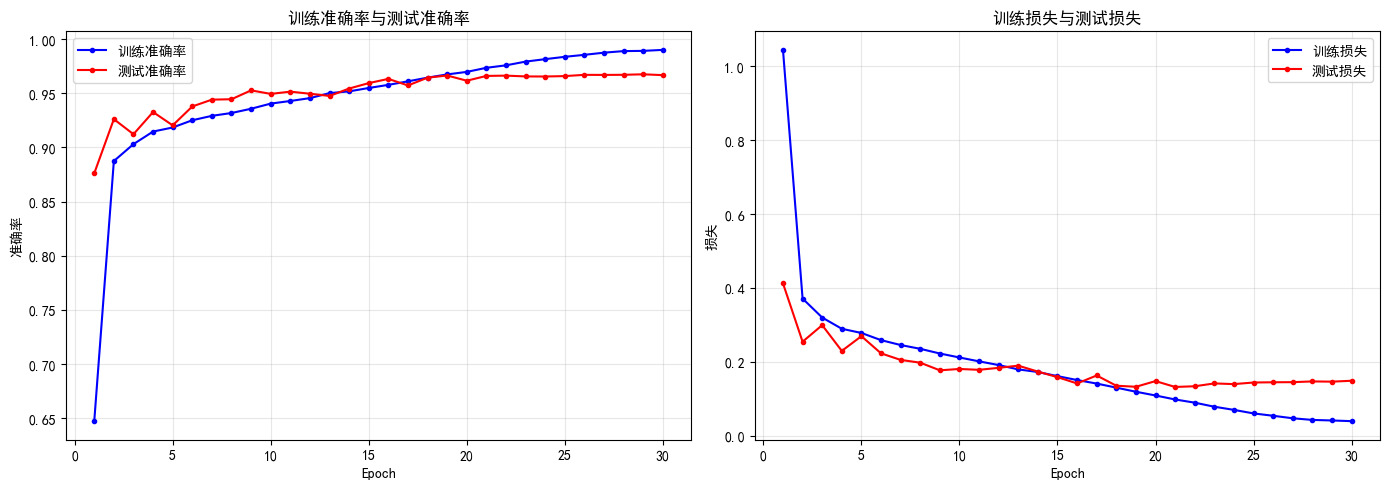

最佳测试准确率: 0.9674 (96.74%)


In [14]:
# 绘制训练/测试准确率曲线
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 准确率曲线
axes[0].plot(epochs_range, train_accs, 'b-o', markersize=3, label='训练准确率')
axes[0].plot(epochs_range, test_accs, 'r-o', markersize=3, label='测试准确率')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('准确率')
axes[0].set_title('训练准确率与测试准确率')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 损失曲线
axes[1].plot(epochs_range, train_losses, 'b-o', markersize=3, label='训练损失')
axes[1].plot(epochs_range, test_losses, 'r-o', markersize=3, label='测试损失')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('损失')
axes[1].set_title('训练损失与测试损失')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'最佳测试准确率: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)')

## 7. 加载最佳模型并测试

最终测试集准确率: 0.9674 (96.74%)
最终测试集损失: 0.1460


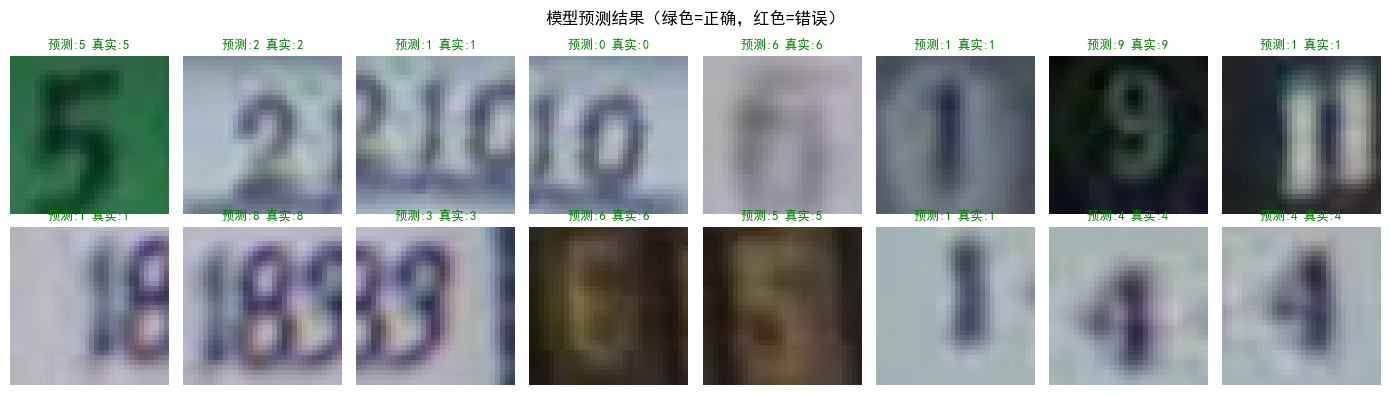

In [15]:
# 加载最佳模型，输出最终测试结果
model.load_state_dict(torch.load('best_model.pth'))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'最终测试集准确率: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'最终测试集损失: {test_loss:.4f}')

# 可视化部分预测结果
model.eval()
images_show, labels_show = next(iter(test_loader))
with torch.no_grad():
    outputs = model(images_show.to(device))
    _, preds = outputs.max(1)
preds = preds.cpu()

# 反归一化用于显示
mean = torch.tensor([0.4377, 0.4438, 0.4728]).view(3, 1, 1)
std = torch.tensor([0.1980, 0.2010, 0.1970]).view(3, 1, 1)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = images_show[i] * std + mean
    img = img.permute(1, 2, 0).numpy().clip(0, 1)
    ax.imshow(img)
    color = 'green' if preds[i] == labels_show[i] else 'red'
    ax.set_title(f'预测:{preds[i].item()} 真实:{labels_show[i].item()}', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('模型预测结果（绿色=正确，红色=错误）')
plt.tight_layout()
plt.show()